## CLASSIFICAÇÃO ONeClassSVM

### PARAMETROS

In [25]:
import numpy

In [ ]:
# PARÂMETROS
random_seed = 42

# FEATURE SELECTION
center_stat = 'mean'

# OneClassSVM
main_flower = None # None, setosa, virginica, versicolor
# gammas = [float(x) for x in numpy.arange(0.01, 2.0, 0.01)]
# gammas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
gammas = [0.001]
nus = [0.2]
kernels = ['rbf']
k_of_k_folds = 5

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [27]:
from itertools import product
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

### IMPORT IRIS

In [28]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
iris['flower'] = 2*(iris['species'] == main_flower) - 1 if main_flower else 1

iris

,sepal_length,sepal_width,petal_length,petal_width,target,species,flower
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica,1
146,6.3,2.5,5.0,1.9,2,virginica,1
147,6.5,3.0,5.2,2.0,2,virginica,1
148,6.2,3.4,5.4,2.3,2,virginica,1


### PAIRPLOT

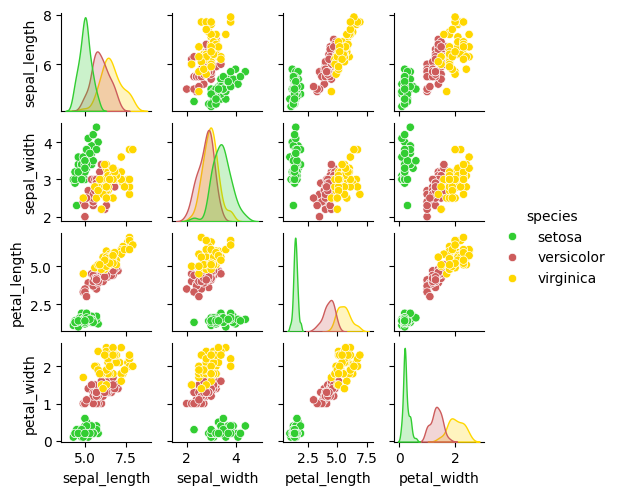

In [29]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.25)

### SELEÇÃO DO TOP 2 ATRIBUTOS

In [30]:
all_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
centers = iris.groupby(['species'])[all_cols].agg(center_stat).T
max_diff = (centers.T.max() - centers.T.min()).sort_values(ascending=False)

max_diff

petal_length    4.090
petal_width     1.780
sepal_length    1.582
sepal_width     0.658
dtype: float64

In [31]:
x_cols_sorted = max_diff.index.tolist()[:2]

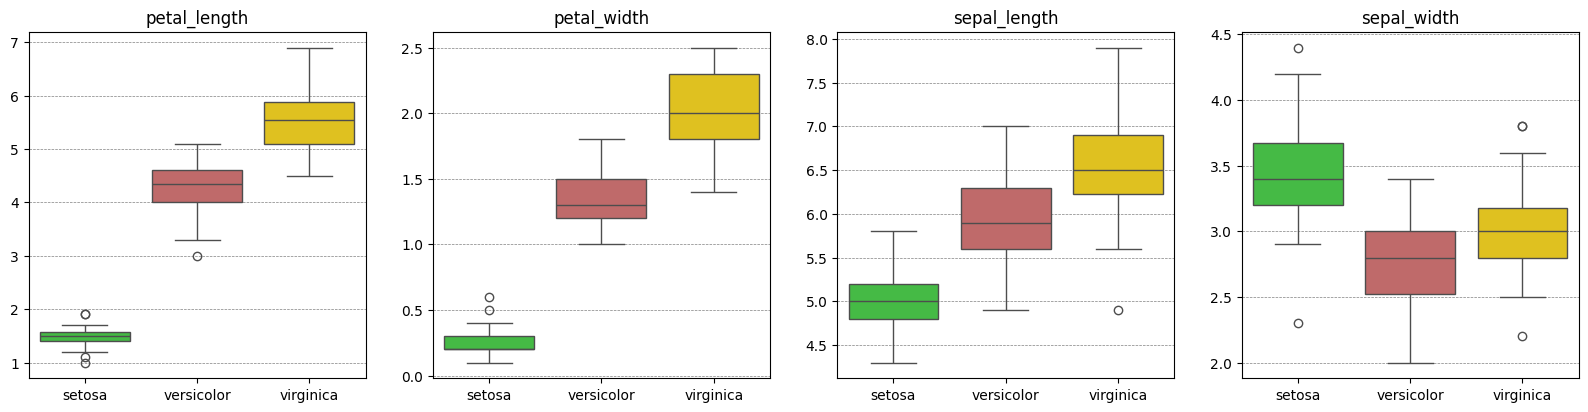

In [32]:
x_cols_sorted = max_diff.index.tolist()

# BOXPLOT DOS ATRIBUTOS VS CLASSE
fig, axs = pyplot.subplots(1, 4, figsize=(20, 4.5))
for i, ax in enumerate(axs.flatten()):
    seaborn.boxplot(x='species', y=x_cols_sorted[i], data=iris, ax=ax, hue='species', dodge=False, palette=palette)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(x_cols_sorted[i])
    ax.grid(which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)

In [33]:
x_cols = x_cols_sorted[:2]

x_cols

['petal_length', 'petal_width']

### LOOP DE TREINAMENTO

> FOLDS VS GAMMA

In [34]:
# RANDOM SEED
numpy.random.seed(random_seed)

# LOOP DE TREINAMENTO
iris_train = iris[iris['flower'] == 1]
ix_model = 0
model_list = []
kfolds = StratifiedKFold(n_splits=k_of_k_folds, shuffle=True, random_state=random_seed)
ix_fold = 0
for train_ix, val_ix in kfolds.split(iris_train[x_cols], iris_train['flower']):
    X_train, y_train = iris_train[x_cols].iloc[train_ix], iris_train['flower'].iloc[train_ix]
    X_val, y_val = iris_train[x_cols].iloc[val_ix], iris_train['flower'].iloc[val_ix]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    for kernel in kernels:
        for gamma in gammas:
            for nu in nus:
                svm = OneClassSVM(kernel=kernel,
                                  gamma=gamma,
                                  nu=nu)
                svm.fit(X_train_scaled)
                y_train_pred = svm.predict(X_train_scaled)
                y_val_pred = svm.predict(X_val_scaled)
                train_accuracy = accuracy_score(y_train, y_train_pred)
                val_accuracy = accuracy_score(y_val, y_val_pred)
                algorithm = 'SVM'
                model_name = f"{kernel[:3].upper()}G{gamma}NU{nu}{ix_fold}"
                hyperconfig = f"{kernel[:3].upper()}G{gamma}NU{nu}"
                print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                model_list.append({'ix_model': ix_model,
                                    'algorithm': algorithm,
                                    'model_name': model_name,
                                    'kernel': kernel,
                                    'gamma': gamma,
                                    'nu': nu,
                                    'hyperconfig' : hyperconfig,
                                    'fold': ix_fold,
                                    'stat' : 'train',
                                    'accuracy': accuracy_score(y_train, y_train_pred),
                                    'scaler' : scaler,
                                    'model' : svm})
                model_list.append({'ix_model': ix_model,
                                    'algorithm': algorithm,
                                    'model_name': model_name,
                                    'kernel': kernel,
                                    'gamma': gamma,
                                    'nu': nu,
                                    'hyperconfig' : hyperconfig,
                                    'fold': ix_fold,
                                    'stat' : 'validation',
                                    'accuracy': accuracy_score(y_val, y_val_pred),
                                    'scaler' : scaler,
                                    'model' : svm})
                ix_model += 1
    ix_fold += 1

RBFG0.001NU0.250 > treino: 76.7% | val: 66.7%
RBFG0.001NU0.251 > treino: 73.3% | val: 73.3%
RBFG0.001NU0.252 > treino: 72.5% | val: 63.3%
RBFG0.001NU0.253 > treino: 73.3% | val: 86.7%
RBFG0.001NU0.254 > treino: 78.3% | val: 76.7%


In [35]:
results = pandas.DataFrame(model_list)
results

,ix_model,algorithm,model_name,kernel,gamma,nu,hyperconfig,fold,stat,accuracy,scaler,model
0,0,SVM,RBFG0.001NU0.250,rbf,0.001,0.25,RBFG0.001NU0.25,0,train,0.766667,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
1,0,SVM,RBFG0.001NU0.250,rbf,0.001,0.25,RBFG0.001NU0.25,0,validation,0.666667,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
2,1,SVM,RBFG0.001NU0.251,rbf,0.001,0.25,RBFG0.001NU0.25,1,train,0.733333,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
3,1,SVM,RBFG0.001NU0.251,rbf,0.001,0.25,RBFG0.001NU0.25,1,validation,0.733333,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
4,2,SVM,RBFG0.001NU0.252,rbf,0.001,0.25,RBFG0.001NU0.25,2,train,0.725000,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
5,2,SVM,RBFG0.001NU0.252,rbf,0.001,0.25,RBFG0.001NU0.25,2,validation,0.633333,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
6,3,SVM,RBFG0.001NU0.253,rbf,0.001,0.25,RBFG0.001NU0.25,3,train,0.733333,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
7,3,SVM,RBFG0.001NU0.253,rbf,0.001,0.25,RBFG0.001NU0.25,3,validation,0.866667,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
8,4,SVM,RBFG0.001NU0.254,rbf,0.001,0.25,RBFG0.001NU0.25,4,train,0.783333,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"
9,4,SVM,RBFG0.001NU0.254,rbf,0.001,0.25,RBFG0.001NU0.25,4,validation,0.766667,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"


### PICK DO MELHOR MODELO

In [36]:
ix_validation = results["stat"] == "validation"

mean_accuracy_by_hyperconfig = results.loc[ix_validation, ["hyperconfig", "accuracy"]].groupby(["hyperconfig"]).agg(["mean", "min"]).reset_index()
mean_accuracy_by_hyperconfig.columns = ['h', 'mean_accuracy', 'min_accuracy']
mean_accuracy_by_hyperconfig = mean_accuracy_by_hyperconfig.sort_values(by=['mean_accuracy', 'min_accuracy'], ascending=[False, False])
mean_accuracy_by_hyperconfig

,h,mean_accuracy,min_accuracy
0,RBFG0.001NU0.25,0.733333,0.633333


### PICK DO MELHOR MODELO

In [37]:
best_hyperconfig_row = mean_accuracy_by_hyperconfig.iloc[0, :]
best_hyperconfig = best_hyperconfig_row['h']
best_hyperconfig

'RBFG0.001NU0.25'

In [38]:
best_h_results = results.loc[results['hyperconfig'] == best_hyperconfig, :]
best_model_rank = best_h_results.pivot(index='model_name', columns='stat', values='accuracy').sort_values(by=['validation', 'train'], ascending=[False, False])
best_model_rank

stat,train,validation
model_name,,
RBFG0.001NU0.253,0.733333,0.866667
RBFG0.001NU0.254,0.783333,0.766667
RBFG0.001NU0.251,0.733333,0.733333
RBFG0.001NU0.250,0.766667,0.666667
RBFG0.001NU0.252,0.725000,0.633333


In [39]:
best_model_row = best_model_rank.iloc[0, :]
best_model_name = best_model_row.name
best_model_name

'RBFG0.001NU0.253'

In [40]:
best_model_row = results.loc[(results['model_name'] == best_model_name) & (results['stat'] == 'validation'), :]
best_model_row

,ix_model,algorithm,model_name,kernel,gamma,nu,hyperconfig,fold,stat,accuracy,scaler,model
7,3,SVM,RBFG0.001NU0.253,rbf,0.001,0.25,RBFG0.001NU0.25,3,validation,0.866667,StandardScaler(),"OneClassSVM(gamma=0.001, nu=0.25)"


In [41]:
best_model = best_model_row["model"].iloc[0]
best_model_scaler = best_model_row["scaler"].iloc[0]

In [42]:
print(f"Melhor modelo: {best_model_row['model_name'].iloc[0]} > validation: {100.0*best_model_row['accuracy'].iloc[0]:.1f}%")

Melhor modelo: RBFG0.001NU0.253 > validation: 86.7%


### MATRIZ DE CONFUSÃO

In [43]:
Xs = best_model_scaler.transform(iris[x_cols])
y = iris['flower'].to_numpy()
winner_y_pred = best_model.predict(Xs)
ok_class = []
for ix in range(len(y)):
    ok_class.append(y[ix] == winner_y_pred[ix])

In [44]:
iris[[not ok for ok in ok_class]]

,sepal_length,sepal_width,petal_length,petal_width,target,species,flower
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1
8,4.4,2.9,1.4,0.2,0,setosa,1
9,4.9,3.1,1.5,0.1,0,setosa,1
12,4.8,3.0,1.4,0.1,0,setosa,1
13,4.3,3.0,1.1,0.1,0,setosa,1
14,5.8,4.0,1.2,0.2,0,setosa,1
22,4.6,3.6,1.0,0.2,0,setosa,1


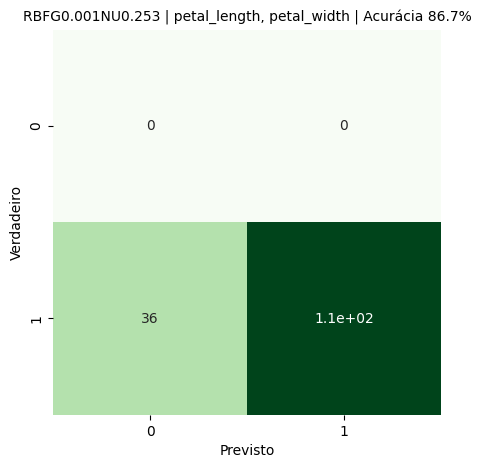

In [45]:
fig = pyplot.figure(figsize=(5, 5))
# PLOT CONFUSION MATRIX
conf_matrix = confusion_matrix(y, winner_y_pred)

ax = fig.add_subplot(111)
_ = seaborn.heatmap(conf_matrix, annot=True, cmap='Greens', cbar=False, ax=ax)
_ = ax.set_xlabel('Previsto')
_ = ax.set_ylabel('Verdadeiro')
# _ = ax.set_xticklabels(iris['flower'].unique(), rotation=45, ha='right')
# _ = ax.set_yticklabels(iris['flower'].unique(), rotation=0, ha='right')
# _ = ax.set_title(f'Vencedor: {winner.fk} | treino {100.0*winner_train_accuracy:.0f}% | teste {100.0*winner.hit:.0f}%')
best_feat_string = ', '.join(x_cols)
_ = ax.set_title(f'{best_model_row['model_name'].iloc[0]} | {best_feat_string} | Acurácia {100.0*best_model_row['accuracy'].iloc[0]:.1f}%', size=10)

In [46]:
# CLASS COLOR GRID & CLASS EVALUATION
grid_n_points = 500
grid_expansion_factor = 1.5
species = [-1, 1]

# X0 W JITTER
X_plot = iris[x_cols].to_numpy()
x0_grid = numpy.linspace(0, grid_expansion_factor*X_plot[:, 0].max(), grid_n_points)
x1_grid = numpy.linspace(0, grid_expansion_factor*X_plot[:, 1].max(), grid_n_points)
X_g = numpy.array(list(product(x0_grid, x1_grid)))
df_X_g = pandas.DataFrame(X_g, columns=x_cols)
X_g_scaled = best_model_scaler.transform(df_X_g)
Y_g = best_model.predict(X_g_scaled)
Y_g_class = Y_g
Y_est = best_model.predict(Xs)
Y_class_est = numpy.array([species[x] for x in Y_est])

In [47]:
color_list = ['red', 'green']
background_color_list = ['lightcoral', 'limegreen']
marker_list = ['v', '^']

# GIVE COLOURS TO CLASS
color_dict = {}
bg_color_dict = {}
marker_dict = {}
ix_color = 0
for specie in species:
    color_dict[specie] = color_list[ix_color]
    marker_dict[specie] = marker_list[ix_color]
    bg_color_dict[specie] = background_color_list[ix_color]
    ix_color += 1

color_dict

{-1: 'red', 1: 'green'}

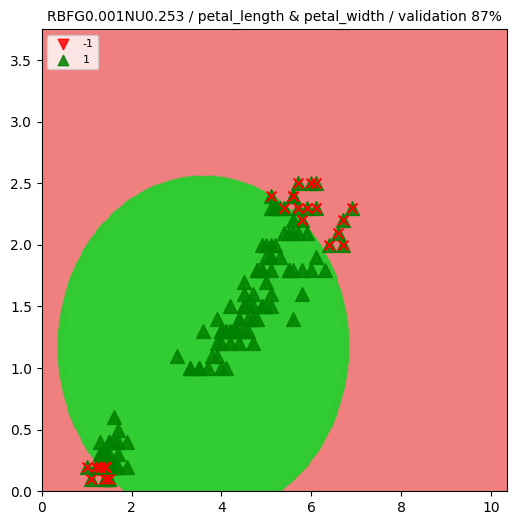

In [48]:
# CLASSIFICATION FIGURE
fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# PLOT CLASS REGION
for specie in species:
    ix_class_cloud = Y_g_class == specie
    x_0_cloud = X_g[ix_class_cloud, 0]
    x_1_cloud = X_g[ix_class_cloud, 1]
    _ = ax.scatter(x_0_cloud, x_1_cloud, marker='o', color=bg_color_dict[specie], alpha=0.25)

# PLOT FLOWERS
for specie in species:
    ix_class = iris['flower'] == specie
    x_0 = X_plot[ix_class, 0]
    x_1 = X_plot[ix_class, 1]
    _ = ax.scatter(x_0, x_1, color=color_dict[specie], marker=marker_dict[specie], alpha=0.85, s=100, label=specie)
    _ = ax.legend(loc='upper left', fontsize=8, markerscale=0.75)

# PLOT MISCLASSFIED TAG
nok_vectors = X_plot[[not ok for ok in ok_class]]
_ = ax.scatter(nok_vectors[:, 0], nok_vectors[:, 1], color='red', marker='x', s=50, label='Misclassified')
_ = ax.set_xlim([0.0, X_g[:, 0].max()])
_ = ax.set_ylim([0.0, X_g[:, 1].max()])
_ = ax.set_title(f"{best_model_row['model_name'].iloc[0]} / {' & '.join(x_cols)} / validation {100.0*best_model_row['accuracy'].iloc[0]:.0f}%", size=10)

CONFUSÃO + ROC + SUPERFÍCIE DE SEPARAÇÃO MELHOR MODELO

LEARNING CURVE MELHOR K VS REGRESSÃO LOGÍSTICA

FLUTUAÇÃO DOS PARÂMETROS DA REGRESSÃO LOGÍSTICA